# Medical Chatbot Berbasis Sentence-BERT

> Dataset: gabungan **ruslanmv/ai-medical-chatbot** dan **tejas1206/medical-chatbot** dari Hugging Face.


## LANGKAH 1: Instalasi Library

> `nltk` untuk preprocessing NLP, `scikit-learn` untuk TF-IDF vectorizer, dan `ipywidgets` untuk tampilan chatbot

In [1]:
!pip install nltk scikit-learn pandas numpy ipywidgets sentence-transformers datasets gradio -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.5 MB/s eta 0:00:00


##  LANGKAH 2: Import Library & Download NLTK Data

 `punkt` digunakan untuk tokenisasi kalimat, `stopwords` untuk menghapus kata-kata umum yang tidak bermakna (seperti 'the', 'is', 'dan'), dan `wordnet` untuk lemmatisasi (mengubah kata ke bentuk dasarnya).

In [2]:
# import library
import nltk
import re
import random
import string
import warnings
import pandas as pd
import numpy as np

# menonaktifkan warning
warnings.filterwarnings('ignore')

# pemrosesan teks
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# representasi dan kemiripan teks
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# download resource NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Sentence-BERT
try:
    from sentence_transformers import SentenceTransformer, util

    # load model multilingual
    SBERT_MODEL = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

    # menandakan SBERT berhasil digunakan
    USE_SBERT = True

except Exception as e:
    # menggunakan metode lain jika SBERT tidak tersedia
    USE_SBERT = False

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## LANGKAH 3: Dataset Medis dari Hugging Face

Dataset diambil dan digabung dari dua sumber di Hugging Face:
>
> - `ruslanmv/ai-medical-chatbot` (kolom `Description`, `Patient`, `Doctor`)
> - `tejas1206/medical-chatbot` (struktur kolom dideteksi otomatis)
>
Karena kedua dataset ini adalah kumpulan percakapan pasien-dokter (bukan FAQ berkategori),
kategori penyakit **diperkirakan otomatis** dari kata kunci pada pertanyaan pasien.


In [5]:
import pandas as pd
import re
from datasets import load_dataset

SAMPLE_SIZE_PER_DATASET = 1500   # jumlah baris yang diambil dari MASING-MASING dataset
FINAL_SAMPLE_SIZE = 1200         # jumlah baris final setelah digabung & dibersihkan
RANDOM_SEED = 42


def load_hf_dataset_safely(name, n_rows, split_name="train"):
    """
    Memuat dataset dari HuggingFace dan hanya mengambil n_rows baris pertama,
    supaya kita tidak perlu mengunduh seluruh dataset (yang bisa sangat besar).
    Kalau slicing gagal (mis. nama split berbeda), fallback ke load penuh lalu potong manual.
    """
    try:
        ds = load_dataset(name, split=f"{split_name}[:{n_rows}]")
    except Exception:
        ds_full = load_dataset(name)
        split_key = split_name if split_name in ds_full else list(ds_full.keys())[0]
        ds = ds_full[split_key].select(range(min(n_rows, len(ds_full[split_key]))))
    return ds


print("Memuat dataset 1: ruslanmv/ai-medical-chatbot ...")
ds1 = load_hf_dataset_safely("ruslanmv/ai-medical-chatbot", SAMPLE_SIZE_PER_DATASET)
print(f"  -> {len(ds1)} baris, kolom: {ds1.column_names}")

print("Memuat dataset 2: tejas1206/medical-chatbot ...")
ds2 = load_hf_dataset_safely("tejas1206/medical-chatbot", SAMPLE_SIZE_PER_DATASET)
print(f"  -> {len(ds2)} baris, kolom: {ds2.column_names}")


def standardize_qa(dataset, question_col=None, answer_col=None, source_name="dataset"):
    """
    Mengubah dataset HuggingFace menjadi DataFrame dengan kolom 'question' dan 'answer'.
    Kalau question_col/answer_col tidak diberikan, dicoba deteksi otomatis dari
    beberapa pasangan nama kolom yang umum dipakai dataset chatbot medis.
    """
    df_raw = dataset.to_pandas()
    cols = list(df_raw.columns)

    # pasangan nama kolom (question, answer) yang umum ditemukan di dataset chatbot medis
    known_pairs = [
        ("Patient", "Doctor"),
        ("question", "answer"),
        ("Question", "Answer"),
        ("input", "output"),
        ("instruction", "response"),
        ("instruction", "output"),
        ("prompt", "completion"),
        ("patient_message", "doctor_response"),
    ]

    if question_col and answer_col:
        q_col, a_col = question_col, answer_col
    else:
        q_col, a_col = None, None
        for q, a in known_pairs:
            if q in cols and a in cols:
                q_col, a_col = q, a
                break

    if q_col is None or a_col is None:
        text_cols = [c for c in cols if df_raw[c].dtype == object]
        if source_name == "medical-chatbot" and len(text_cols) == 1 and text_cols[0] == 'text':
            # Specific handling for 'tejas1206/medical-chatbot' which has a single 'text' column.
            # We assume a conversational format like "patient: ... doctor: ..."
            questions = []
            answers = []
            for entry in df_raw['text'].astype(str):
                q_text = ""
                a_text = ""

                patient_idx = entry.lower().find('patient:')
                doctor_idx = entry.lower().find('doctor:')

                if patient_idx != -1 and doctor_idx != -1:
                    if patient_idx < doctor_idx:
                        # Format: patient: [Q] doctor: [A]
                        q_text = entry[patient_idx + len('patient:'):doctor_idx].strip()
                        a_text = entry[doctor_idx + len('doctor:'):].strip()
                    else:
                        # Format: doctor: [A] patient: [Q] (less common, but possible)
                        a_text = entry[doctor_idx + len('doctor:'):patient_idx].strip()
                        q_text = entry[patient_idx + len('patient:'):].strip()
                elif patient_idx != -1:
                    # Only patient: found, assume it's a question
                    q_text = entry[patient_idx + len('patient:'):].strip()
                elif doctor_idx != -1:
                    # Only doctor: found, assume it's an answer without a preceding question
                    a_text = entry[doctor_idx + len('doctor:'):].strip()
                else:
                    # No specific markers, treat the whole entry as a question
                    q_text = entry.strip()

                questions.append(q_text)
                answers.append(a_text)

            temp_df = pd.DataFrame({'question': questions, 'answer': answers})
            # Filter out entries where both question and answer are empty or too short
            temp_df = temp_df[(temp_df['question'].str.len() > 5) | (temp_df['answer'].str.len() > 5)]

            q_col, a_col = 'question', 'answer'
            df_raw = temp_df # Use the processed df_raw for the rest of the function
            cols = ['question', 'answer'] # Update cols for consistency
            print(f"[{source_name}] Kolom 'text' dipecah menjadi 'question' dan 'answer' secara heuristik.")
        elif len(text_cols) >= 2:
            q_col, a_col = text_cols[0], text_cols[1]
            print(
                f"[{source_name}] Kolom question/answer tidak dikenali otomatis, "
                f"pakai '{q_col}' sebagai question dan '{a_col}' sebagai answer. "
                f"Sesuaikan manual kalau salah. Kolom tersedia: {cols}"
            )
        else:
            raise ValueError(
                f"[{source_name}] Tidak bisa menemukan kolom question/answer. "
                f"Kolom tersedia: {cols}. Perlu setidaknya 2 kolom teks "
                f"atau kolom 'text' dengan format 'patient: ... doctor: ...'."
            )

    out = pd.DataFrame(
        {
            "question": df_raw[q_col].astype(str),
            "answer": df_raw[a_col].astype(str),
            "source": source_name,
        }
    )
    return out


df1 = standardize_qa(ds1, question_col="Patient", answer_col="Doctor", source_name="ai-medical-chatbot")
df2 = standardize_qa(ds2, source_name="medical-chatbot")  # auto-detect kolom


def clean_text_field(text, max_len=700):
    """membersihkan whitespace berlebih & memotong teks yang kepanjangan"""
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    # buang salam pembuka pasien/dokter yang umum (Hi doctor, Hello Dr. dst)
    text = re.sub(r"^(hi|hello|hey)[\s,!. ]*(doctor|dr\.?)?[\s,!:.-]*", "", text, flags=re.IGNORECASE)
    if len(text) > max_len:
        text = text[:max_len].rsplit(" ", 1)[0] + "..."
    return text.strip()


df_combined = pd.concat([df1, df2], ignore_index=True)
df_combined["question"] = df_combined["question"].apply(lambda t: clean_text_field(t, max_len=200))
df_combined["answer"] = df_combined["answer"].apply(lambda t: clean_text_field(t, max_len=800))

# buang baris kosong / terlalu pendek / duplikat
df_combined = df_combined[df_combined["question"].str.len() > 5]
df_combined = df_combined[df_combined["answer"].str.len() > 5]
df_combined = df_combined.drop_duplicates(subset="question").reset_index(drop=True)

# KATEGORISASI OTOMATIS berdasarkan kata kunci pada pertanyaan
# (dataset asli tidak punya label kategori, jadi kita perkirakan sendiri)
CATEGORY_KEYWORDS = {
    "diabetes": ["diabetes", "blood sugar", "insulin", "glucose"],
    "hipertensi": ["hypertension", "blood pressure", "high bp"],
    "jantung": ["heart attack", "chest pain", "cardiac", "heart disease", "palpitation"],
    "sakit kepala": ["headache", "migraine"],
    "asma": ["asthma", "wheezing", "inhaler", "shortness of breath"],
    "demam": ["fever", "high temperature"],
    "batuk pilek": ["cough", "cold", "flu", "sore throat", "runny nose"],
    "maag": ["stomach pain", "gastritis", "acid reflux", "ulcer", "abdominal pain"],
    "kolesterol": ["cholesterol", "ldl", "hdl"],
    "kulit": ["rash", "skin", "itching", "acne"],
    "kesehatan mental": ["depression", "anxiety", "stress", "mental health", "panic"],
    "covid": ["covid", "coronavirus"],
    "kehamilan": ["pregnant", "pregnancy"],
    "kesehatan anak": ["baby", "infant", "toddler", "my child"],
}


def detect_category(text):
    text_lower = text.lower()
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in text_lower for kw in keywords):
            return category
    return "umum"


df_combined["category"] = df_combined["question"].apply(detect_category)

# sampling akhir per kategori supaya total data tetap ringan untuk TF-IDF/SBERT
n_categories = df_combined["category"].nunique()
per_category_cap = max(5, FINAL_SAMPLE_SIZE // n_categories)
if len(df_combined) > FINAL_SAMPLE_SIZE:
    df_combined = (
        df_combined.groupby("category", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), per_category_cap), random_state=RANDOM_SEED))
        .reset_index(drop=True)
    )

df = df_combined[["category", "question", "answer"]].sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print("Dataset berhasil dimuat & digabung!")
print(f"Total pasangan Q&A: {len(df)}")
print(f"Kategori: {', '.join(sorted(df['category'].unique()))}")
print("\n5 contoh data pertama:")
df[["category", "question"]].head()

Memuat dataset 1: ruslanmv/ai-medical-chatbot ...
  -> 1500 baris, kolom: ['Description', 'Patient', 'Doctor']
Memuat dataset 2: tejas1206/medical-chatbot ...
  -> 1500 baris, kolom: ['text']
[medical-chatbot] Kolom 'text' dipecah menjadi 'question' dan 'answer' secara heuristik.
Dataset berhasil dimuat & digabung!
Total pasangan Q&A: 1004
Kategori: asma, batuk pilek, demam, diabetes, hipertensi, jantung, kehamilan, kesehatan anak, kesehatan mental, kolesterol, kulit, maag, sakit kepala, umum

5 contoh data pertama:


,category,question
0,kulit,I am having red rashes on the glands of the pe...
1,kulit,I have itching in the penis area. Kindly advice.
2,umum,I am 21 and suffering from tinnitus from last ...
3,umum,Pain after idiopathic orbital inflammation bef...
4,sakit kepala,I would like to ask about my symptoms. It star...


##  LANGKAH 4: NLP Preprocessing Pipeline

> 1. **Normalisasi** -> lowercase, hapus tanda baca
> 2. **Tokenisasi** -> pecah teks menjadi token (kata)
> 3. **Lemmatisasi** -> ubah ke bentuk dasar (running -> run, gejala-gejala -> gejala)
>
> Untuk bahasa Indonesia, kita tambahkan stopwords manual karena NLTK tidak menyediakan stopwords Bahasa Indonesia secara default.

In [6]:
# membuat lemmatizer
lemmatizer = WordNetLemmatizer()

# stopwords bahasa indonesia
indonesian_stopwords = {
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk',
    'pada', 'adalah', 'atau', 'juga', 'dalam', 'tidak', 'akan', 'ada',
    'saya', 'kamu', 'anda', 'ia', 'mereka', 'kami', 'kita', 'bisa',
    'sudah', 'bila', 'jika', 'maka', 'oleh', 'karena', 'apa',
    'bagaimana', 'berapa', 'kapan', 'dimana', 'siapa', 'apakah', 'cara',
    'lebih', 'sangat', 'dapat', 'nya', 'pun', 'lagi', 'belum',
    'telah', 'namun', 'tapi', 'serta', 'meski', 'agar', 'supaya', 'hal',
    'the', 'is', 'are', 'was', 'what', 'how', 'why', 'when', 'where'
}

english_stopwords = set(stopwords.words('english'))
all_stopwords = indonesian_stopwords | english_stopwords

# preprocessing teks
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# test preprocessing
print("Test preprocessing:")
for t in ["sakit kepala", "gejala maag", "pusing berputar"]:
    print(f"  '{t}' → '{preprocess_text(t)}'")

df['processed_question'] = df['question'].apply(preprocess_text)

Test preprocessing:
  'sakit kepala' → 'sakit kepala'
  'gejala maag' → 'gejala maag'
  'pusing berputar' → 'pusing berputar'


## LANGKAH 5: TF-IDF Vectorizer + Cosine Similarity

TF-IDF (Term Frequency-Inverse Document Frequency) adalah teknik klasik NLP yang sangat efektif untuk mencocokkan pertanyaan. Cara kerjanya:
> - **TF (Term Frequency)**: seberapa sering kata muncul dalam dokumen
> - **IDF (Inverse Document Frequency)**: seberapa unik kata tersebut di seluruh corpus
> - **Cosine Similarity**: mengukur kemiripan dua vektor (1 = identik, 0 = tidak mirip)
>
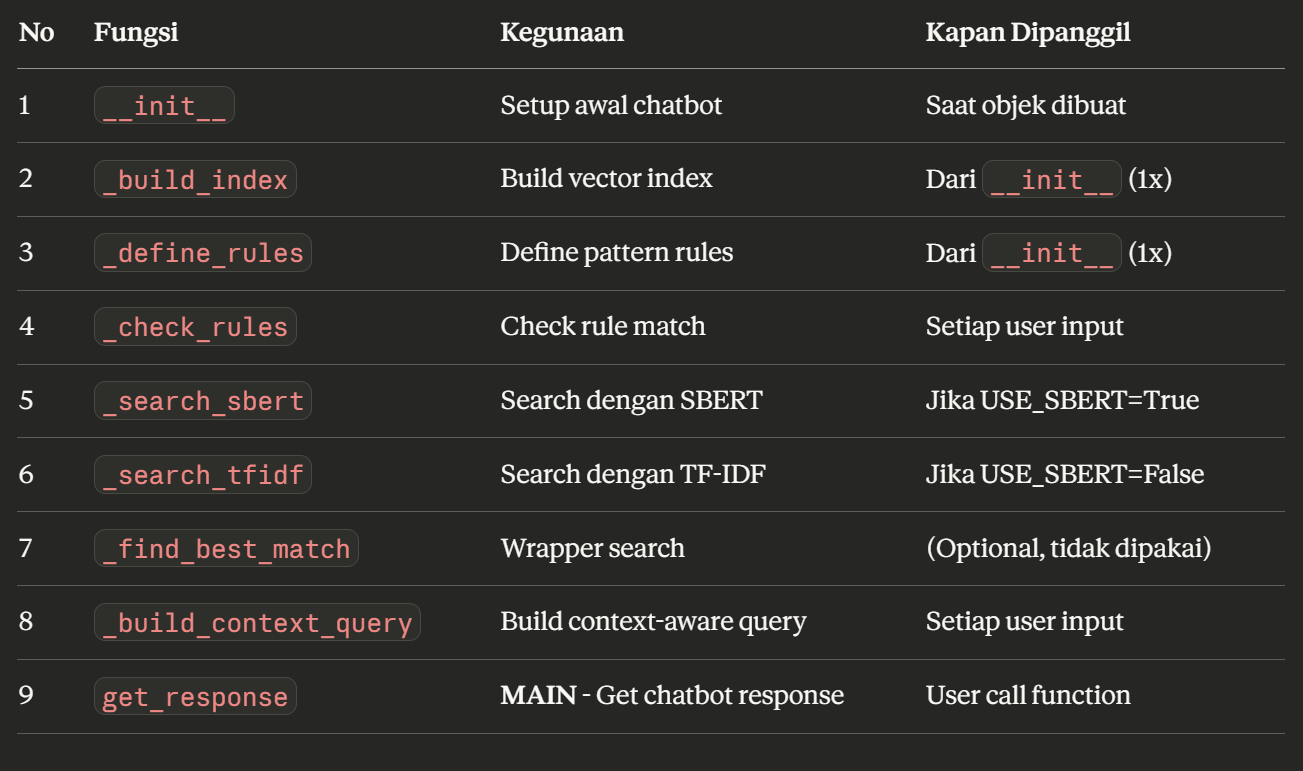



In [7]:
class MedicalChatbotEngineV3:

    # menginisialisasi dataset, threshold similarity, jumlah kandidat, dan komponen utama chatbot
    def __init__(self, dataframe, threshold=0.35, top_k=3):
        self.df = dataframe

        # menggunakan threshold 0.35 untuk SBERT dan 0.15 jika menggunakan TF-IDF
        self.threshold = threshold if USE_SBERT else 0.15

        # menentukan jumlah kandidat FAQ dengan similarity tertinggi yang akan dipertimbangkan
        self.top_k = top_k

        # menyimpan input pengguna sebelumnya untuk memberikan konteks pada pertanyaan berikutnya
        self.conversation_history = []

        # menyiapkan representasi data FAQ dan rule khusus saat chatbot dibuat
        self._build_index()
        self._define_rules()


    # menyiapkan representasi seluruh pertanyaan FAQ untuk proses pencarian similarity
    def _build_index(self):
        if USE_SBERT:

            # mengubah seluruh pertanyaan asli pada dataset menjadi embedding SBERT
            self.sbert_embeddings = SBERT_MODEL.encode(
                self.df['question'].tolist(),
                convert_to_tensor=True
            )

        # membuat vectorizer TF-IDF sebagai metode pencarian alternatif
        self.vectorizer = TfidfVectorizer(

            # menggunakan unigram dan bigram sebagai fitur
            ngram_range=(1, 2),

            # membatasi jumlah fitur maksimal sebanyak 5000
            max_features=5000,

            # mengurangi pengaruh kata yang muncul terlalu sering
            sublinear_tf=True
        )

        # mempelajari vocabulary dan mengubah processed_question menjadi matrix TF-IDF
        self.tfidf_matrix = self.vectorizer.fit_transform(
            self.df['processed_question']
        )


    # mendefinisikan rule untuk input yang dapat ditangani langsung tanpa pencarian FAQ
    def _define_rules(self):
        self.rules = {

            # mendeteksi beberapa pola kata yang menunjukkan kondisi darurat
            # (pola Bahasa Indonesia + Inggris, karena dataset sekarang mayoritas Inggris)
            'emergency': {
                'patterns': [
                    r'(sesak.*berat|nyeri dada.*berat|tidak.*bernapas|pingsan)',
                    r'(severe chest pain|can.?t breathe|difficulty breathing|unconscious|not breathing|heart attack)',
                ],

                # response langsung jika input cocok dengan pola kondisi darurat
                'responses': [
                    "🚨 DARURAT! Hubungi 119 atau segera ke IGD!"
                ]
            },

            # mendeteksi input yang berupa sapaan dari pengguna
            'greeting': {
                'patterns': [
                    r'\b(halo|hai|hi|hello|hey|good morning|good afternoon)\b'
                ],

                # response langsung jika input merupakan sapaan
                'responses': [
                    "👋 Halo! Ada yang bisa saya bantu?"
                ]
            }
        }


    # mengecek apakah input pengguna cocok dengan salah satu pola pada rules
    def _check_rules(self, text):

        # memeriksa setiap intent dan pattern yang sudah didefinisikan
        for intent, data in self.rules.items():
            for pattern in data['patterns']:

                # mencari kecocokan pattern regex pada input yang sudah diubah menjadi lowercase
                if re.search(pattern, text.lower()):

                    # mengambil salah satu response dari rule yang sesuai
                    return random.choice(data['responses'])

        # mengembalikan None jika tidak ada rule yang cocok
        return None


    # mencari kandidat FAQ berdasarkan kemiripan makna menggunakan Sentence-BERT
    def _search_sbert(self, query):
        from sentence_transformers import util

        # mengubah pertanyaan pengguna menjadi embedding SBERT
        emb = SBERT_MODEL.encode(query, convert_to_tensor=True)

        # menghitung cosine similarity antara embedding query dan seluruh embedding FAQ
        scores = util.cos_sim(emb, self.sbert_embeddings)[0]

        # mengubah hasil similarity dari tensor menjadi array NumPy
        scores = scores.cpu().numpy()

        # mengurutkan score dari tertinggi dan mengambil sejumlah top_k kandidat terbaik
        top_results = np.argsort(-scores)[:self.top_k]

        # mengembalikan index FAQ beserta similarity score masing-masing kandidat
        return [(idx, float(scores[idx])) for idx in top_results]


    # mencari kandidat FAQ berdasarkan kemiripan vector menggunakan TF-IDF
    def _search_tfidf(self, query):

        # membersihkan dan menormalisasi query menggunakan fungsi preprocessing
        processed = preprocess_text(query)

        # mengubah query yang sudah diproses menjadi vector berdasarkan vocabulary TF-IDF
        vec = self.vectorizer.transform([processed])

        # menghitung cosine similarity antara vector query dan seluruh vector FAQ
        scores = cosine_similarity(vec, self.tfidf_matrix).flatten()

        # mengurutkan score dari tertinggi dan mengambil sejumlah top_k kandidat terbaik
        top_results = np.argsort(scores)[::-1][:self.top_k]

        # mengembalikan index FAQ beserta similarity score masing-masing kandidat
        return [(idx, scores[idx]) for idx in top_results]


    # memilih metode pencarian sesuai ketersediaan SBERT dan mengambil kandidat terbaik
    def _find_best_match(self, query):

        # menggunakan SBERT sebagai metode utama dan TF-IDF sebagai alternatif
        if USE_SBERT:
            results = self._search_sbert(query)
        else:
            results = self._search_tfidf(query)

        # mengambil kandidat pertama karena hasil sudah diurutkan dari score tertinggi
        best_idx, best_score = results[0]

        # mengembalikan index FAQ terbaik dan similarity score-nya
        return best_idx, best_score


    # membuat query dengan mempertimbangkan input sebelumnya sebagai konteks percakapan
    def _build_context_query(self, user_input):

        # mengecek apakah sudah terdapat percakapan sebelumnya
        if len(self.conversation_history) > 0:

            # mengambil input pengguna yang paling terakhir
            last_input = self.conversation_history[-1]

            # menggabungkan input sebelumnya dengan input baru agar query memiliki konteks
            return last_input + " " + user_input

        # menggunakan input secara langsung jika belum terdapat riwayat percakapan
        return user_input


    # mengatur seluruh alur pemrosesan input hingga menghasilkan response chatbot
    def get_response(self, user_input):

        # memastikan pengguna tidak mengirim input kosong atau hanya berisi spasi
        if not user_input.strip():
            return "Silakan ketik pertanyaan."

        # mengecek terlebih dahulu apakah input termasuk kondisi yang memiliki rule khusus
        rule = self._check_rules(user_input)

        # langsung mengembalikan response jika ditemukan rule yang sesuai
        if rule:
            return rule

        # membuat query dengan menambahkan konteks dari percakapan sebelumnya jika tersedia
        query = self._build_context_query(user_input)

        # menggunakan SBERT sebagai metode utama jika model tersedia
        if USE_SBERT:
            results = self._search_sbert(query)
            method = "SBERT"

        # menggunakan TF-IDF sebagai metode alternatif jika SBERT tidak tersedia
        else:
            results = self._search_tfidf(query)
            method = "TF-IDF"

        # mengambil kandidat dengan similarity score tertinggi
        best_idx, best_score = results[0]

        # menolak hasil jika similarity score belum mencapai batas minimum relevansi
        if best_score < self.threshold:
            return "🤔 Tidak menemukan jawaban yang cukup relevan."

        # menyiapkan list untuk menyimpan kandidat setelah diberikan tambahan keyword score
        boosted = []

        # mengevaluasi kembali seluruh kandidat top_k berdasarkan kecocokan kata
        for idx, score in results:

            # mengambil teks pertanyaan FAQ berdasarkan index kandidat
            text = self.df.iloc[idx]['question']

            # menghitung jumlah kata input pengguna yang juga terdapat pada pertanyaan FAQ
            bonus = sum(1 for word in user_input.split() if word in text)

            # menambahkan bonus 0.05 untuk setiap kata yang cocok dengan pertanyaan FAQ
            boosted.append((idx, score + 0.05 * bonus))

        # mengurutkan kandidat berdasarkan score setelah keyword boost dan mengambil yang tertinggi
        best_idx = sorted(boosted, key=lambda x: x[1], reverse=True)[0][0]

        # mengambil seluruh data FAQ dari kandidat terbaik
        row = self.df.iloc[best_idx]

        # menyimpan input pengguna agar dapat digunakan sebagai konteks pertanyaan berikutnya
        self.conversation_history.append(user_input)

        # menampilkan kategori, metode pencarian, jawaban FAQ, dan peringatan medis
        return f"""
[Kategori: {row['category']} | {method}]

{row['answer']}

─────────────────
⚠️ Untuk kondisi serius, konsultasikan ke dokter.
"""


## LANGKAH 6: Tampilan Interaktif di Google Colab

`ipywidgets` untuk membuat UI chat yang interaktif langsung di Colab. Ini memungkinkan pengguna berinteraksi dengan chatbot tanpa perlu menjalankan ulang cell setiap saat.

In [8]:
# UI CHATBOT INTERAKTIF
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

chat_css = """
<style>
  @import url('https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;500;600;700&display=swap');
  .medbot-container { font-family: 'Plus Jakarta Sans', sans-serif; max-width: 720px; margin: 0 auto; border-radius: 20px; overflow: hidden; box-shadow: 0 20px 60px rgba(0,0,0,0.15); background: #f8faff; }
  .medbot-header { background: linear-gradient(135deg, #1a1f5e 0%, #2d3a8c 50%, #1565c0 100%); padding: 20px 24px; color: white; display: flex; align-items: center; gap: 14px; }
  .medbot-avatar { width: 48px; height: 48px; background: rgba(255,255,255,0.2); border-radius: 50%; display: flex; align-items: center; justify-content: center; font-size: 24px; border: 2px solid rgba(255,255,255,0.4); }
  .medbot-title { font-size: 18px; font-weight: 700; }
  .medbot-subtitle { font-size: 12px; opacity: 0.75; margin-top: 2px; }
  .status-dot { width:8px; height:8px; background:#4ade80; border-radius:50%; display:inline-block; margin-right:5px; animation: pulse 2s infinite; }
  @keyframes pulse { 0%,100%{opacity:1} 50%{opacity:0.5} }
  .medbot-chat { height: 400px; overflow-y: auto; padding: 20px; background: #f0f4ff; display: flex; flex-direction: column; gap: 14px; }
  .message-row-user { display:flex; justify-content:flex-end; }
  .message-row-bot  { display:flex; justify-content:flex-start; align-items:flex-start; gap:10px; }
  .bot-icon { width: 32px; height: 32px; min-width: 32px; background: linear-gradient(135deg, #1565c0, #2d3a8c); border-radius: 50%; display: flex; align-items:center; justify-content:center; font-size: 14px; }
  .bubble-user { background: linear-gradient(135deg, #1565c0, #2d3a8c); color: white; padding: 12px 16px; border-radius: 18px 18px 4px 18px; max-width: 75%; font-size: 14px; line-height: 1.5; }
  .bubble-bot { background: white; color: #1a1a2e; padding: 12px 16px; border-radius: 18px 18px 18px 4px; max-width: 80%; font-size: 13.5px; line-height: 1.65; box-shadow: 0 2px 10px rgba(0,0,0,0.08); border: 1px solid #e8eeff; white-space: pre-wrap; }
  .disclaimer { background: #fff8e1; border-left: 3px solid #f59e0b; padding: 10px 14px; font-size: 11.5px; color: #78350f; }
  .quick-chips { padding: 10px 16px; background: white; border-top: 1px solid #f0f0ff; display: flex; gap: 8px; flex-wrap: wrap; }
  .chip { background: #eef2ff; color: #2d3a8c; border: 1px solid #c7d2fe; border-radius: 20px; padding: 5px 12px; font-size: 12px; font-weight: 500; cursor: pointer; font-family: inherit; }
  .chip:hover { background: #2d3a8c; color: white; }
  .badge-sbert { background: #d1fae5; color: #065f46; border-radius: 12px; padding: 2px 8px; font-size: 10px; font-weight: 600; margin-left: 8px; }
</style>
"""

chat_messages = []

def render_chat():
    mode_badge = '<span class="badge-sbert">Sentence-BERT</span>' if USE_SBERT else '<span style="background:#fee2e2;color:#991b1b;border-radius:12px;padding:2px 8px;font-size:10px;font-weight:600;margin-left:8px;">TF-IDF</span>'
    html = chat_css
    html += '<div class="medbot-container">'
    html += f'''
    <div class="medbot-header">
      <div class="medbot-avatar">🏥</div>
      <div>
        <div class="medbot-title">MedBot v2 — Asisten Kesehatan{mode_badge}</div>
        <div class="medbot-subtitle"><span class="status-dot"></span>Online · Semantic Medical QA Engine</div>
      </div>
    </div>
    '''
    html += '<div class="disclaimer">⚠️ MedBot hanya untuk edukasi. Bukan pengganti dokter. Darurat medis: hubungi 119.</div>'
    html += '''
    <div class="quick-chips">
      <span class="chip">🤕 Sakit Kepala</span>
      <span class="chip">🩸 Diabetes</span>
      <span class="chip">❤️ Jantung</span>
      <span class="chip">🫁 Asma</span>
      <span class="chip">🦠 COVID-19</span>
      <span class="chip">🧠 Mental</span>
    </div>
    '''
    html += '<div class="medbot-chat">'
    if not chat_messages:
        html += '<div class="message-row-bot"><div class="bot-icon">🤖</div><div class="bubble-bot">👋 Halo! Saya <strong>MedBot v2</strong>, kini dengan <strong>Sentence-BERT</strong> untuk pemahaman bahasa yang lebih baik!\n\nTopik baru: 🤕 Sakit kepala & migrain\n\nSilakan ketik pertanyaan kesehatan Anda!</div></div>'
    for msg in chat_messages:
        if msg['role'] == 'user':
            html += f'<div class="message-row-user"><div class="bubble-user">{msg["content"]}</div></div>'
        else:
            html += f'<div class="message-row-bot"><div class="bot-icon">🤖</div><div class="bubble-bot">{msg["content"]}</div></div>'
    html += '</div></div>'
    return HTML(html)

text_input = widgets.Text(
    placeholder='Ketik pertanyaan... (coba: "sakit kepala", "gejala diabetes")',
    layout=widgets.Layout(width='82%', height='38px')
)
send_button = widgets.Button(description='Kirim 📤', button_style='primary', layout=widgets.Layout(width='10%', height='38px'))
clear_button = widgets.Button(description='Clear 🗑️', button_style='warning', layout=widgets.Layout(width='8%', height='38px'))
output_area = widgets.Output()

def send_message(b=None):
    global chat_messages
    user_text = text_input.value.strip()
    if not user_text:
        return
    chat_messages.append({'role': 'user', 'content': user_text})
    response = bot.get_response(user_text)
    chat_messages.append({'role': 'bot', 'content': response})
    text_input.value = ''
    with output_area:
        clear_output(wait=True)
        display(render_chat())

def clear_chat(b):
    global chat_messages
    chat_messages = []
    with output_area:
        clear_output(wait=True)
        display(render_chat())

send_button.on_click(send_message)
clear_button.on_click(clear_chat)
text_input.on_submit(lambda w: send_message())

input_bar = widgets.HBox([text_input, send_button, clear_button], layout=widgets.Layout(padding='10px', gap='8px'))

with output_area:
    display(render_chat())

display(output_area)
display(input_bar)
print("Tip: Ketik pertanyaan lalu tekan Enter atau klik 'Kirim'")

Output()

Tip: Ketik pertanyaan lalu tekan Enter atau klik 'Kirim'


In [9]:
import gradio as gr
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# INIT BOT
bot = MedicalChatbotEngineV3(df)

# RESPOND (STREAMING)
def respond(message, history):
    if history is None:
        history = []

    # tampilkan typing effect
    history.append((message, "⏳ MedBot sedang mengetik"))
    yield "", history

    time.sleep(0.6)
    response = bot.get_response(message)

    # update chat
    history[-1] = (message, response)
    yield "", history


# CHIP RESPONSE
def respond_chip(message, history):
    if history is None:
        history = []

    response = bot.get_response(message)

    history.append((message, response))
    return "", history


# CLEAR CHAT + MEMORY RESET
def clear_chat():
    bot.conversation_history = []  # reset context
    return []

# CSS
custom_css = """
.gradio-container {
    font-family: 'Plus Jakarta Sans', sans-serif;
    background: #f0f4ff;
}

.chatbot {
    height: 420px;
}

/* USER */
.message.user-message {
    background: linear-gradient(135deg, #1565c0, #2d3a8c) !important;
    color: white !important;
    border-radius: 18px 18px 4px 18px !important;
}

/* BOT */
.message.bot-message {
    background: white !important;
    border-radius: 18px 18px 18px 4px !important;
    border: 1px solid #e8eeff;
}

.header {
    background: linear-gradient(135deg, #1a1f5e, #2d3a8c, #1565c0);
    padding: 20px;
    border-radius: 15px;
    color: white;
}

.disclaimer {
    background: #fff8e1;
    padding: 10px;
    font-size: 12px;
    border-left: 4px solid orange;
    margin-top: 10px;
}
"""


# UI
with gr.Blocks(css=custom_css) as demo:
    # HEADER
    gr.Markdown("""
    <div class="header">
        <h2>🏥 MedBot v3 — Smart Medical Assistant</h2>
        <p>🟢 Online · Context-Aware Semantic Engine</p>
    </div>
    """)

    # DISCLAIMER
    gr.Markdown("""
    <div class="disclaimer">
    ⚠️ Edukasi saja. Bukan pengganti dokter. Darurat: 119
    </div>
    """)

    chatbot = gr.Chatbot()
    msg = gr.Textbox(placeholder="Ketik pertanyaan kesehatan...")

    with gr.Row():
        send = gr.Button("Kirim 📤")
        clear = gr.Button("Clear 🗑️")

    # QUICK CHIPS
    with gr.Row():
        chip1 = gr.Button("🤕 Sakit Kepala")
        chip2 = gr.Button("🩸 Diabetes")
        chip3 = gr.Button("❤️ Jantung")
        chip4 = gr.Button("🫁 Asma")
        chip5 = gr.Button("🧠 Mental")

    # EVENT
    send.click(respond, [msg, chatbot], [msg, chatbot])
    msg.submit(respond, [msg, chatbot], [msg, chatbot])

    clear.click(clear_chat, None, chatbot, queue=False)

    # CHIP EVENTS
    chip1.click(lambda h: respond_chip("sakit kepala", h), chatbot, [msg, chatbot])
    chip2.click(lambda h: respond_chip("diabetes", h), chatbot, [msg, chatbot])
    chip3.click(lambda h: respond_chip("penyakit jantung", h), chatbot, [msg, chatbot])
    chip4.click(lambda h: respond_chip("asma", h), chatbot, [msg, chatbot])
    chip5.click(lambda h: respond_chip("kesehatan mental", h), chatbot, [msg, chatbot])


demo.queue()
demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://baa990a2bff6e6ec6e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## LANGKAH 7: Analisis & Evaluasi Chatbot

distribusi dataset, top TF-IDF features, dan akurasi intent detection.

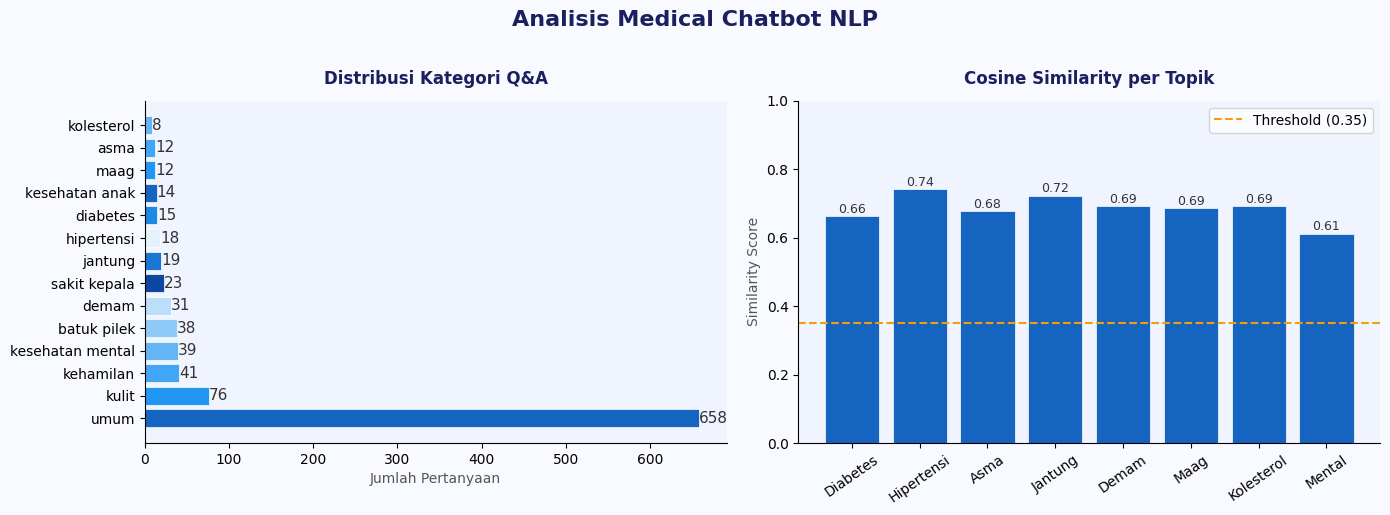

In [10]:
# ANALISIS DATASET & MODEL
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8faff')
plt.suptitle('Analisis Medical Chatbot NLP', fontsize=16, fontweight='bold', color='#1a1f5e', y=1.02)

# Plot 1: Distribusi Kategori
category_counts = df['category'].value_counts()
colors = ['#1565c0', '#2196f3', '#42a5f5', '#64b5f6', '#90caf9',
          '#bbdefb', '#0d47a1', '#1976d2', '#e3f2fd', '#1e88e5']
axes[0].barh(category_counts.index, category_counts.values,
             color=colors[:len(category_counts)], edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Kategori Q&A', fontweight='bold', color='#1a1f5e', pad=12)
axes[0].set_xlabel('Jumlah Pertanyaan', color='#555')
axes[0].set_facecolor('#f0f4ff')
axes[0].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(category_counts.values):
    axes[0].text(v + 0.05, i, str(v), va='center', fontsize=11, color='#333')

# Plot 2: Similarity Score untuk berbagai pertanyaan test
test_cases = [
    ("diabetes symptoms blood sugar", "Diabetes"),
    ("high blood pressure hypertension", "Hipertensi"),
    ("asthma attack inhaler", "Asma"),
    ("chest pain heart attack", "Jantung"),
    ("fever high temperature", "Demam"),
    ("stomach pain acid reflux", "Maag"),
    ("high cholesterol ldl", "Kolesterol"),
    ("anxiety stress depression", "Mental"),
]

labels, scores = [], []
for query, label in test_cases:
    idx, score = bot._find_best_match(query)
    labels.append(label)
    scores.append(score)

bar_colors = ['#1565c0' if s >= bot.threshold else '#ef5350' for s in scores]
bars = axes[1].bar(labels, scores, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].axhline(y=bot.threshold, color='#f59e0b', linestyle='--', linewidth=1.5, label=f'Threshold ({bot.threshold:.2f})')
axes[1].set_title('Cosine Similarity per Topik', fontweight='bold', color='#1a1f5e', pad=12)
axes[1].set_ylabel('Similarity Score', color='#555')
axes[1].set_ylim(0, 1)
axes[1].set_facecolor('#f0f4ff')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].legend(fontsize=10)
axes[1].tick_params(axis='x', rotation=35)
for bar, score in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.2f}', ha='center', fontsize=9, color='#333')

plt.tight_layout()
plt.savefig('medbot_analysis.png', dpi=150, bbox_inches='tight', facecolor='#f8faff')
plt.show()


##  LANGKAH 8: Batch Testing & Evaluasi

batch testing dengan pertanyaan yang bervariasi untuk melihat kemampuan generalisasi chatbot. Ini mirip dengan evaluasi model ML biasa.

In [11]:
# evaluasi chatbot

# Catatan: karena dataset sekarang mayoritas berbahasa Inggris, skenario tes
# disesuaikan ke Bahasa Inggris. Skenario 'capability' pada versi lama dihapus
# karena bot ini tidak punya rule khusus untuk pertanyaan "topik apa saja".
test_scenarios = [
    ("i have a headache", "sakit kepala", "Headache langsung"),
    ("my head hurts and pulsing pain", "sakit kepala", "Paraphrase migrain"),
    ("diabetes symptoms high blood sugar", "diabetes", "Diabetes langsung"),
    ("my blood sugar is high", "diabetes", "Paraphrase diabetes"),
    ("high blood pressure hypertension", "hipertensi", "Hipertensi langsung"),
    ("how to treat shortness of breath asthma", "asma", "Pengobatan asma"),
    ("chest pain radiating to my arm", "jantung", "Gejala jantung"),
    ("stomach pain acid reflux nausea", "maag", "Gejala maag (bukan kepala)"),
    ("feeling sad and no motivation lately", "kesehatan mental", "Gejala depresi"),
    ("hello good morning", "greeting", "Salam"),
    ("random topic that does not exist xyzabc", "unknown", "Out-of-scope"),
]

print("LAPORAN EVALUASI MEDBOT")

# menghitung jumlah prediksi yang benar
correct = 0

for user_input, expected_cat, description in test_scenarios:
    response = bot.get_response(user_input)
    response_lower = response.lower()

    # mengecek kesesuaian response dengan kategori yang diharapkan
    is_correct = (
        expected_cat in response_lower or
        (expected_cat == 'greeting' and ('halo' in response_lower or 'hai' in response_lower)) or
        (expected_cat == 'capability' and 'topik' in response_lower) or
        (expected_cat == 'unknown' and ('tidak menemukan' in response_lower or 'tidak' in response_lower))
    )

    status = "✅" if is_correct else "❌"

    if is_correct:
        correct += 1

    print(f"\n{status} [{description}]")
    print(f"   Input   : '{user_input}'")
    print(f"   Expected: {expected_cat}")

    first_line = response.split('\n')[0]
    print(f"   Response: {first_line}")

# menghitung akurasi dari seluruh test scenario
accuracy = correct / len(test_scenarios) * 100

print(f"HASIL EVALUASI: {correct}/{len(test_scenarios)} benar ({accuracy:.1f}% akurasi)")



LAPORAN EVALUASI MEDBOT

✅ [Headache langsung]
   Input   : 'i have a headache'
   Expected: sakit kepala
   Response: 

✅ [Paraphrase migrain]
   Input   : 'my head hurts and pulsing pain'
   Expected: sakit kepala
   Response: 

✅ [Diabetes langsung]
   Input   : 'diabetes symptoms high blood sugar'
   Expected: diabetes
   Response: 

✅ [Paraphrase diabetes]
   Input   : 'my blood sugar is high'
   Expected: diabetes
   Response: 

✅ [Hipertensi langsung]
   Input   : 'high blood pressure hypertension'
   Expected: hipertensi
   Response: 

✅ [Pengobatan asma]
   Input   : 'how to treat shortness of breath asthma'
   Expected: asma
   Response: 

✅ [Gejala jantung]
   Input   : 'chest pain radiating to my arm'
   Expected: jantung
   Response: 

✅ [Gejala maag (bukan kepala)]
   Input   : 'stomach pain acid reflux nausea'
   Expected: maag
   Response: 

❌ [Gejala depresi]
   Input   : 'feeling sad and no motivation lately'
   Expected: kesehatan mental
   Response: 

✅ [Salam]
   I